In [2]:
import pandas as pd

In [1]:
from google.colab import files
uploaded = files.upload()


Saving patient_priority[1].csv to patient_priority[1].csv


In [3]:
df = pd.read_csv('patient_priority[1].csv')


In [4]:
print(df.shape)
print(df.columns.tolist())
df.head()


(6962, 18)
['Unnamed: 0', 'age', 'gender', 'chest pain type', 'blood pressure', 'cholesterol', 'max heart rate', 'exercise angina', 'plasma glucose', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'hypertension', 'heart_disease', 'Residence_type', 'smoking_status', 'triage']


,Unnamed: 0,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,Residence_type,smoking_status,triage
0,0,40.0,1.0,2.0,140.0,294.0,172.0,0.0,108.0,43.0,92.0,19.0,0.467386,0.0,0.0,Urban,never smoked,yellow
1,1,49.0,0.0,3.0,160.0,180.0,156.0,0.0,75.0,47.0,90.0,18.0,0.467386,0.0,0.0,Urban,never smoked,orange
2,2,37.0,1.0,2.0,130.0,294.0,156.0,0.0,98.0,53.0,102.0,23.0,0.467386,0.0,0.0,Urban,never smoked,yellow
3,3,48.0,0.0,4.0,138.0,214.0,156.0,1.0,72.0,51.0,118.0,18.0,0.467386,0.0,0.0,Urban,never smoked,orange
4,4,54.0,1.0,3.0,150.0,195.0,156.0,0.0,108.0,90.0,83.0,21.0,0.467386,0.0,0.0,Urban,never smoked,yellow


In [5]:
print(df.isnull().sum())
print(df.dtypes)

Unnamed: 0             0
age                    0
gender                 1
chest pain type        0
blood pressure         0
cholesterol            0
max heart rate         0
exercise angina        0
plasma glucose         0
skin_thickness         0
insulin                0
bmi                    0
diabetes_pedigree      0
hypertension           0
heart_disease          0
Residence_type         0
smoking_status         0
triage               410
dtype: int64
Unnamed: 0             int64
age                  float64
gender               float64
chest pain type      float64
blood pressure       float64
cholesterol          float64
max heart rate       float64
exercise angina      float64
plasma glucose       float64
skin_thickness       float64
insulin              float64
bmi                  float64
diabetes_pedigree    float64
hypertension         float64
heart_disease        float64
Residence_type        object
smoking_status        object
triage                object
dtype: object


In [6]:
for col in df.columns:
    print(col, "->", df[col].unique()[:5])

Unnamed: 0 -> [0 1 2 3 4]
age -> [40. 49. 37. 48. 54.]
gender -> [ 1.  0. nan]
chest pain type -> [2. 3. 4. 1. 0.]
blood pressure -> [140. 160. 130. 138. 150.]
cholesterol -> [294. 180. 214. 195. 237.]
max heart rate -> [172. 156. 170. 142. 145.]
exercise angina -> [0. 1.]
plasma glucose -> [108.  75.  98.  72.  86.]
skin_thickness -> [43. 47. 53. 51. 90.]
insulin -> [ 92.  90. 102. 118.  83.]
bmi -> [19. 18. 23. 21. 22.]
diabetes_pedigree -> [0.46738601 0.167      2.288      0.201      0.248     ]
hypertension -> [0. 1.]
heart_disease -> [0. 1.]
Residence_type -> ['Urban' 'Rural']
smoking_status -> ['never smoked' 'smokes' 'formerly smoked' 'Unknown']
triage -> ['yellow' 'orange' 'red' nan 'green']


In [7]:
df.head(7)

,Unnamed: 0,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,Residence_type,smoking_status,triage
0,0,40.0,1.0,2.0,140.0,294.0,172.0,0.0,108.0,43.0,92.0,19.0,0.467386,0.0,0.0,Urban,never smoked,yellow
1,1,49.0,0.0,3.0,160.0,180.0,156.0,0.0,75.0,47.0,90.0,18.0,0.467386,0.0,0.0,Urban,never smoked,orange
2,2,37.0,1.0,2.0,130.0,294.0,156.0,0.0,98.0,53.0,102.0,23.0,0.467386,0.0,0.0,Urban,never smoked,yellow
3,3,48.0,0.0,4.0,138.0,214.0,156.0,1.0,72.0,51.0,118.0,18.0,0.467386,0.0,0.0,Urban,never smoked,orange
4,4,54.0,1.0,3.0,150.0,195.0,156.0,0.0,108.0,90.0,83.0,21.0,0.467386,0.0,0.0,Urban,never smoked,yellow
5,5,39.0,1.0,3.0,120.0,294.0,170.0,0.0,86.0,49.0,106.0,21.0,0.467386,0.0,0.0,Urban,never smoked,orange
6,6,45.0,0.0,2.0,130.0,237.0,170.0,0.0,116.0,39.0,97.0,23.0,0.467386,0.0,0.0,Urban,never smoked,yellow


In [8]:
target_col='triage'
df = df.dropna(subset=[target_col])
for col in df.columns:
    if col != target_col:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

print("Shape after cleaning:", df.shape)
print(df.isnull().sum())

Shape after cleaning: (6552, 18)
Unnamed: 0           0
age                  0
gender               0
chest pain type      0
blood pressure       0
cholesterol          0
max heart rate       0
exercise angina      0
plasma glucose       0
skin_thickness       0
insulin              0
bmi                  0
diabetes_pedigree    0
hypertension         0
heart_disease        0
Residence_type       0
smoking_status       0
triage               0
dtype: int64


In [9]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
label_encoders = {}
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        label_encoders[col]=le
df_encoded.head()

,Unnamed: 0,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,Residence_type,smoking_status,triage
0,0,40.0,1.0,2.0,140.0,294.0,172.0,0.0,108.0,43.0,92.0,19.0,0.467386,0.0,0.0,1,2,3
1,1,49.0,0.0,3.0,160.0,180.0,156.0,0.0,75.0,47.0,90.0,18.0,0.467386,0.0,0.0,1,2,1
2,2,37.0,1.0,2.0,130.0,294.0,156.0,0.0,98.0,53.0,102.0,23.0,0.467386,0.0,0.0,1,2,3
3,3,48.0,0.0,4.0,138.0,214.0,156.0,1.0,72.0,51.0,118.0,18.0,0.467386,0.0,0.0,1,2,1
4,4,54.0,1.0,3.0,150.0,195.0,156.0,0.0,108.0,90.0,83.0,21.0,0.467386,0.0,0.0,1,2,3


In [10]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5241, 17)
Test shape: (1311, 17)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))

Baseline Accuracy: 0.9366895499618612
              precision    recall  f1-score   support

           0       0.90      0.94      0.92        88
           1       0.73      0.46      0.57        69
           2       0.56      0.19      0.29        26
           3       0.95      0.98      0.97      1128

    accuracy                           0.94      1311
   macro avg       0.78      0.65      0.69      1311
weighted avg       0.93      0.94      0.93      1311



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        88
           1       1.00      1.00      1.00        69
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00      1128

    accuracy                           1.00      1311
   macro avg       1.00      1.00      1.00      1311
weighted avg       1.00      1.00      1.00      1311



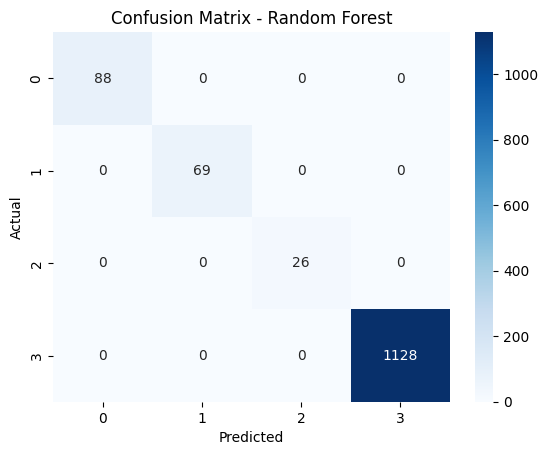

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [13]:
correlations = df_encoded.corr()[target_col].sort_values(ascending=False)
print(correlations)

triage               1.000000
age                  0.167447
Unnamed: 0           0.090540
bmi                  0.072889
skin_thickness       0.050853
max heart rate      -0.003322
blood pressure      -0.013424
heart_disease       -0.014131
exercise angina     -0.020365
smoking_status      -0.022869
insulin             -0.031093
cholesterol         -0.032871
diabetes_pedigree   -0.045844
hypertension        -0.046294
Residence_type      -0.056894
chest pain type     -0.068144
gender              -0.074299
plasma glucose      -0.609508
Name: triage, dtype: float64


In [14]:
importances = pd.Series(rf_model.feature importances, index=X.columns)
print(importances.sort_values(ascending=False))
print("Duplicate rows:", df_encoded.duplicated().sum())


plasma glucose       0.309862
age                  0.180980
blood pressure       0.174321
bmi                  0.116736
chest pain type      0.063592
Unnamed: 0           0.046914
cholesterol          0.023695
skin_thickness       0.017160
smoking_status       0.013051
diabetes_pedigree    0.010814
gender               0.010496
insulin              0.010399
max heart rate       0.010043
Residence_type       0.006990
hypertension         0.002497
exercise angina      0.001892
heart_disease        0.000560
dtype: float64
Duplicate rows: 0


In [15]:
!pip install shap -q

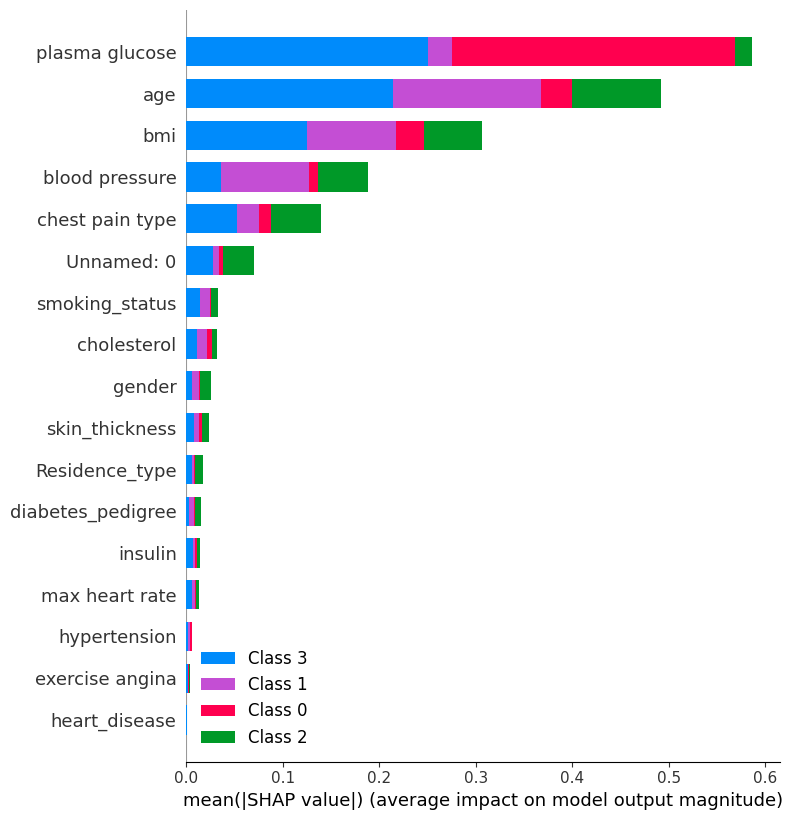

In [16]:
import shap
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [18]:
import joblib
joblib.dump(rf_model, 'triage_model.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')



['feature_columns.pkl']

In [19]:
from google.colab import files
files.download('triage_model.pkl')
files.download('label_encoders.pkl')
files.download('feature_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
feature_columns = joblib.load('feature_columns.pkl')
print(feature_columns)

['Unnamed: 0', 'age', 'gender', 'chest pain type', 'blood pressure', 'cholesterol', 'max heart rate', 'exercise angina', 'plasma glucose', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'hypertension', 'heart_disease', 'Residence_type', 'smoking_status']
